In [2]:
# ── Cell 0.1: Imports ─────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [3]:
# ── Cell 0.2: Paths & Style ───────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11

cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    FIGURES_PATH   = os.path.join("..", "outputs", "figures")
    PROCESSED_PATH = os.path.join("..", "data", "processed")
    ENV_PATH       = "../.env"
else:
    FIGURES_PATH   = os.path.join("outputs", "figures")
    PROCESSED_PATH = os.path.join("data", "processed")
    ENV_PATH       = ".env"

os.makedirs(FIGURES_PATH, exist_ok=True)
print(f"✓ Figures  → {os.path.abspath(FIGURES_PATH)}")

✓ Figures  → C:\Users\jabez\Documents\ai-job-displacement-observatory\outputs\figures


In [4]:
# ── Cell 0.3: Connections & Configuration ────────────────────────────────────
load_dotenv(ENV_PATH)

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Verify database connection
with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM bls_oews")).scalar()
print(f"✓ Database connected. bls_oews: {count:,} rows")

# Verify OpenAI key exists before spending time on anything else
api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env — add it before continuing.")
client = OpenAI(api_key=api_key)
print(f"✓ OpenAI client initialized (key ending: ...{api_key[-6:]})")

# Configuration
MODEL          = "gpt-4o"
TEMPERATURE    = 0.3
MAX_TOKENS     = 650
N_BRIEFINGS    = 50
MAX_PER_OCC    = 3
MAX_PER_METRO  = 5
DELAY_SECONDS  = 1.0

✓ Database connected. bls_oews: 1,182,597 rows
✓ OpenAI client initialized (key ending: ...philly)


## Section 1 — Database Table Setup

I  created a dedicated `llm_briefings` table to store generated briefings.
Storing in PostgreSQL (rather than a CSV) serves three purposes:

1. **Persistence** — briefings survive notebook restarts and can be queried later
2. **Deduplication** — we can check if a briefing already exists before calling the API,
   so re-running the pipeline never wastes money on already-generated content
3. **Dashboard integration** — Tableau (Part 8) connects directly to PostgreSQL,
   so briefings will be available alongside all other project data

In [5]:
# ── Cell 1.1: Create llm_briefings Table ─────────────────────────────────────
# IF NOT EXISTS means this is safe to re-run — it won't overwrite existing data.

create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS llm_briefings (
        id                   SERIAL PRIMARY KEY,
        occ_code             TEXT,
        occ_title            TEXT,
        area_code            TEXT,
        area_title           TEXT,
        risk_index           NUMERIC(6,4),
        automation_prob      NUMERIC(6,4),
        ai_exposure_score    NUMERIC(6,4),
        emp_trend_risk       NUMERIC(6,4),
        wage_stagnation_risk NUMERIC(6,4),
        tot_emp              NUMERIC(12,2),
        education_req        TEXT,
        briefing_text        TEXT,
        prompt_tokens        INTEGER,
        completion_tokens    INTEGER,
        model                TEXT,
        generated_at         TIMESTAMP DEFAULT NOW()
    );

    CREATE INDEX IF NOT EXISTS idx_briefings_occ_code  ON llm_briefings (occ_code);
    CREATE INDEX IF NOT EXISTS idx_briefings_area_code ON llm_briefings (area_code);
    CREATE INDEX IF NOT EXISTS idx_briefings_risk      ON llm_briefings (risk_index DESC);
""")

with engine.begin() as conn:
    conn.execute(create_table_sql)

with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM llm_briefings")).scalar()

print(f"✓ llm_briefings table ready. Current row count: {count}")

✓ llm_briefings table ready. Current row count: 0


## Section 2 — Selecting the Top 50 Combinations

I don't simply take the 50 rows with the highest risk_index from `risk_index.csv`.
Without a diversity constraint, all 50 briefings could be the same occupation
(e.g., Cashiers) repeated across 50 different cities — which is far less useful
as a policy tool.

Instead, I apply two constraints:
- **Max 3 briefings per occupation** — ensures variety across job types
- **Max 5 briefings per metro area** — ensures geographic spread

This produces a set of 50 briefings that covers diverse occupations and geographies
while still prioritizing the highest-risk combinations.

In [6]:
# ── Cell 2.1: Load Risk Index ─────────────────────────────────────────────────
risk_path = os.path.join(PROCESSED_PATH, "risk_index.csv")
df_risk   = pd.read_csv(risk_path)
df_risk   = df_risk.dropna(subset=['risk_index', 'tot_emp'])

print(f"Total occupation × metro rows: {len(df_risk):,}")
print(f"Risk index range: {df_risk['risk_index'].min():.3f} – {df_risk['risk_index'].max():.3f}")
print(f"Unique occupations:  {df_risk['occ_code'].nunique():,}")
print(f"Unique metro areas:  {df_risk['area_code'].nunique():,}")

Total occupation × metro rows: 167,614
Risk index range: 0.136 – 0.873
Unique occupations:  815
Unique metro areas:  393


In [7]:
# ── Cell 2.2: Select Top 50 with Diversity Constraints ───────────────────────
def select_top_combinations(df, n=N_BRIEFINGS,
                             max_per_occ=MAX_PER_OCC,
                             max_per_metro=MAX_PER_METRO):
    df_sorted    = df.sort_values('risk_index', ascending=False)
    selected     = []
    occ_counts   = {}
    metro_counts = {}

    for _, row in df_sorted.iterrows():
        occ   = row['occ_code']
        metro = row['area_code']

        if occ_counts.get(occ, 0)    >= max_per_occ:   continue
        if metro_counts.get(metro, 0) >= max_per_metro: continue

        selected.append(row)
        occ_counts[occ]     = occ_counts.get(occ, 0)   + 1
        metro_counts[metro] = metro_counts.get(metro, 0) + 1

        if len(selected) >= n:
            break

    return pd.DataFrame(selected).reset_index(drop=True)


df_targets = select_top_combinations(df_risk)

print(f"Selected {len(df_targets)} combinations for briefing generation")
print(f"Unique occupations in selection: {df_targets['occ_code'].nunique()}")
print(f"Unique metro areas in selection: {df_targets['area_code'].nunique()}")
print(f"\nRisk index range in selection:")
print(f"  Min: {df_targets['risk_index'].min():.3f}")
print(f"  Max: {df_targets['risk_index'].max():.3f}")
print(f"  Mean: {df_targets['risk_index'].mean():.3f}")

Selected 50 combinations for briefing generation
Unique occupations in selection: 17
Unique metro areas in selection: 40

Risk index range in selection:
  Min: 0.812
  Max: 0.873
  Mean: 0.836


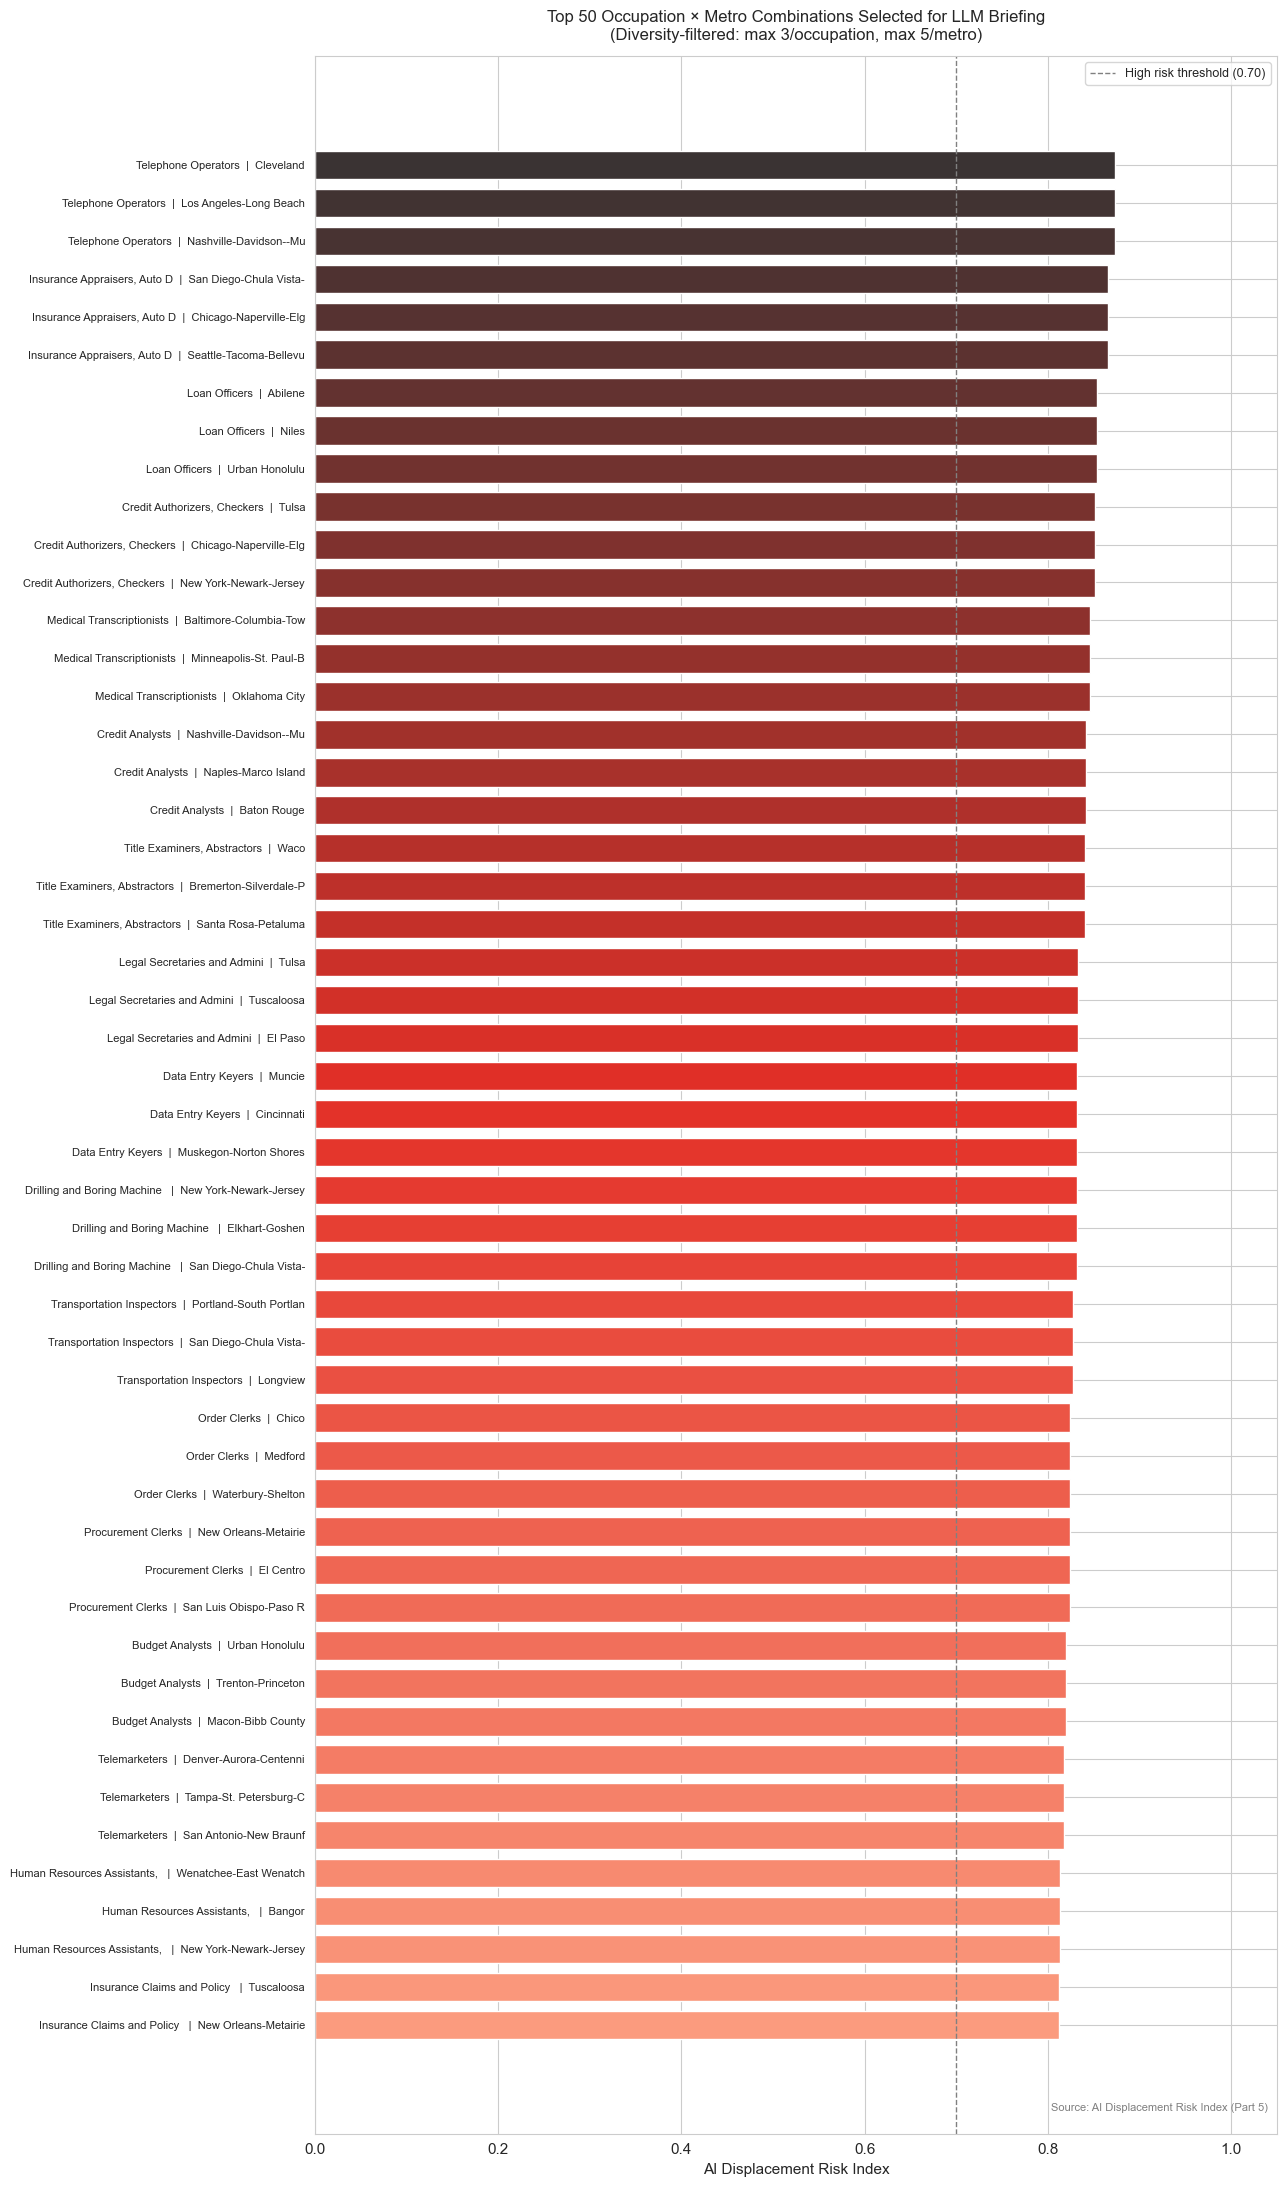

✓ Saved: p7_01_top50_target_distribution.png


In [10]:
# ── Cell 2.3: Chart — Risk Score Distribution of Selected Combinations ────────
df_plot = df_targets.copy()

# Keep labels short — truncate both parts aggressively
df_plot['occ_short']   = df_plot['occ_title'].str[:28]
df_plot['metro_short'] = df_plot['area_title'].str.split(',').str[0].str[:22]
df_plot['label']       = df_plot['occ_short'] + '  |  ' + df_plot['metro_short']

fig, ax = plt.subplots(figsize=(13, 22))   # tall enough for 50 bars

bars = ax.barh(
    df_plot['label'][::-1],
    df_plot['risk_index'][::-1],
    color  = sns.color_palette("Reds_d", len(df_plot)),
    height = 0.75
)

ax.axvline(0.70, color='gray', linestyle='--', linewidth=1,
           label='High risk threshold (0.70)')
ax.set_xlabel("AI Displacement Risk Index", fontsize=11)
ax.set_title(
    f"Top {N_BRIEFINGS} Occupation × Metro Combinations Selected for LLM Briefing\n"
    f"(Diversity-filtered: max {MAX_PER_OCC}/occupation, max {MAX_PER_METRO}/metro)",
    fontsize=12, pad=12
)
ax.tick_params(axis='y', labelsize=8)   # small font so labels don't collide
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)
ax.text(0.99, 0.01, "Source: AI Displacement Risk Index (Part 5)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p7_01_top50_target_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p7_01_top50_target_distribution.png")